# XClinVision-Ops — Data Exploration
**Chest X-ray Abnormality Detection (VinBigData)**

This notebook explores the curated dataset used for training:
- Sample images per pathology class
- Class-distribution analysis (overall & per-split)
- Multi-label statistics & co-occurrence
- Pixel-intensity analysis
- Radiologist agreement analysis
- Image metadata analysis

## 1. Setup & Imports

In [2]:
import os, sys, warnings
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6), "figure.dpi": 100})
warnings.filterwarnings("ignore")

In [3]:
PROJECT_ROOT = Path().absolute().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)
SAVE_DIR = PROJECT_ROOT / "outputs" / "evaluation"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: /home/karim-mache/Documents/nouncode-ai/portfolio_projects/xclinvision-ops


## 2. Load Labels & Splits

In [5]:
def resolve_image(filename: str, search_dir: Path, prefer_ext: str = ".png") -> "Path | None":
    """Find an image file by stem, handling any source extension.

    Tries (in order): preferred extension, original filename, glob fallback.
    """
    stem = Path(filename).stem
    candidate = search_dir / (stem + prefer_ext)
    if candidate.exists():
        return candidate
    candidate = search_dir / filename
    if candidate.exists():
        return candidate
    matches = list(search_dir.glob(f"{stem}.*"))
    return matches[0] if matches else None

print("resolve_image() helper ready.")

resolve_image() helper ready.


In [9]:
data_dir = PROJECT_ROOT / "data" / "raw"
labels = pd.read_csv(data_dir / "labels.csv")
DISEASE_COLS = ["Cardiomegaly", "Aortic enlargement", "Pleural thickening", "Pulmonary fibrosis"]

# Load split assignments
splits = {}
for split in ["train", "val", "test"]:
    with open(f"data/raw/splits/{split}.txt") as f:
        fnames = [l.strip() for l in f if l.strip()]
    splits[split] = fnames

# Add split column
fname2split = {}
for s, fnames in splits.items():
    for fn in fnames:
        fname2split[fn] = s
labels["split"] = labels["filename"].map(fname2split)

# # Is-normal flag
# labels["is_normal"] = (labels[DISEASE_COLS].sum(axis=1) == 0).astype(int)

print(f"Total images : {len(labels):,}")
print(f"Disease cols : {DISEASE_COLS}")
print(f"Splits       : { {s: len(v) for s, v in splits.items()} }")
labels.head()

Total images : 14,304
Disease cols : ['Cardiomegaly', 'Aortic enlargement', 'Pleural thickening', 'Pulmonary fibrosis']
Splits       : {'train': 10020, 'val': 2133, 'test': 2151}


,filename,no finding,Cardiomegaly,Aortic enlargement,Pleural thickening,Pulmonary fibrosis,split
0,0c6a7e3c733bd4f4d89443ca16615fc6.dicom,0,1,1,1,0,train
1,67923e1fdac310042f5feb9f788839bf.dicom,0,0,0,1,0,train
2,19850eb0ba7a72faf4b329254ab42828.dicom,0,0,0,1,1,train
3,8ac52862c96cc0f4a21cb3f5314b2505.dicom,0,0,1,1,0,train
4,8e1a18777633a830c6e5897e4dddb6f7.dicom,0,0,1,1,0,train


## 3. Sample Images per Class

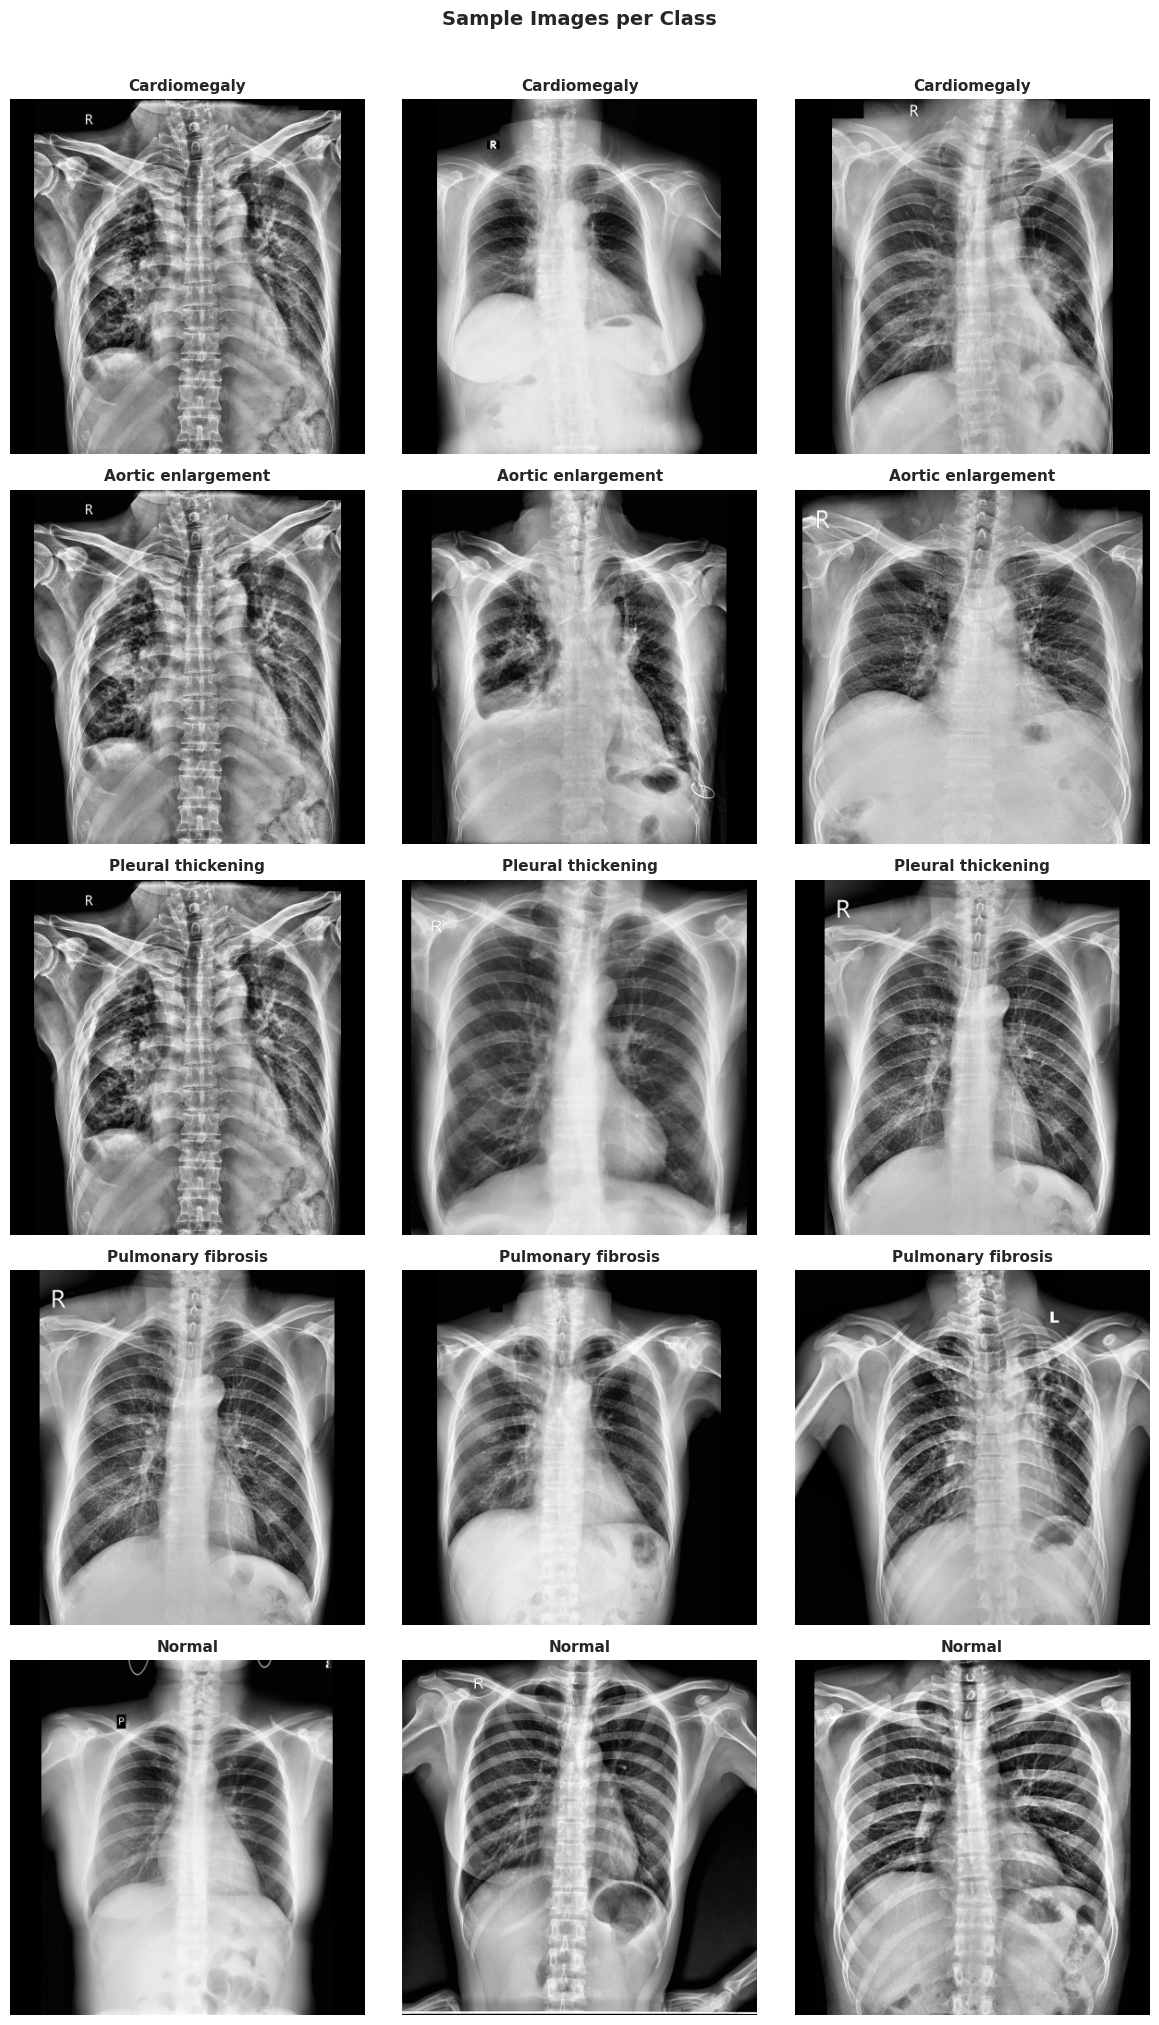

In [22]:
processed_dir = Path("data/processed_384_v2_fa119f/images")
n_samples = 3

categories = {c: labels[labels[c] == 1]["filename"].tolist() for c in DISEASE_COLS}
categories["Normal"] = labels[labels["no finding"] == 1]["filename"].tolist()

fig, axes = plt.subplots(len(categories), n_samples, figsize=(4 * n_samples, 4 * len(categories)))
for row, (cat, fnames) in enumerate(categories.items()):
    chosen = fnames[:n_samples]
    for col, fn in enumerate(chosen):
        img_path = resolve_image(fn, processed_dir)
        if img_path is not None and img_path.exists():
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(f"{cat}", fontsize=11, fontweight="bold")
        axes[row, col].axis("off")
plt.suptitle("Sample Images per Class", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(SAVE_DIR / "sample_images_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Class Distribution (Overall)

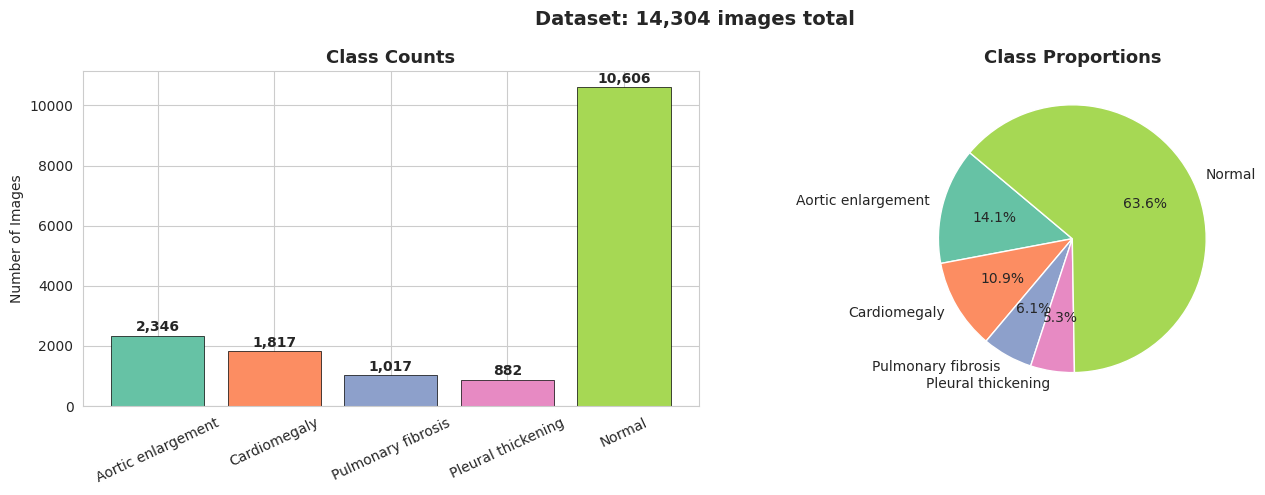

In [13]:
disease_counts = labels[DISEASE_COLS].sum().sort_values(ascending=False)
normal_count = labels["no finding"].sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
all_counts = pd.concat([disease_counts, pd.Series({"Normal": normal_count})])
colors = sns.color_palette("Set2", len(all_counts))
bars = ax1.bar(all_counts.index, all_counts.values, color=colors, edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, all_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f"{int(val):,}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")
ax1.set_title("Class Counts", fontsize=13, fontweight="bold")
ax1.set_ylabel("Number of Images")
ax1.tick_params(axis="x", rotation=25)

# Pie chart
ax2.pie(all_counts.values, labels=all_counts.index, autopct="%1.1f%%",
        colors=colors, startangle=140, textprops={"fontsize": 10})
ax2.set_title("Class Proportions", fontsize=13, fontweight="bold")

plt.suptitle(f"Dataset: {len(labels):,} images total", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Per-Split Distribution

,Normal,Cardiomegaly,Aortic enlargement,Pleural thickening,Pulmonary fibrosis,total
split,,,,,,
train,7425,1272,1642,618,712,10020
val,1591,273,352,132,153,2133
test,1590,272,352,132,152,2151


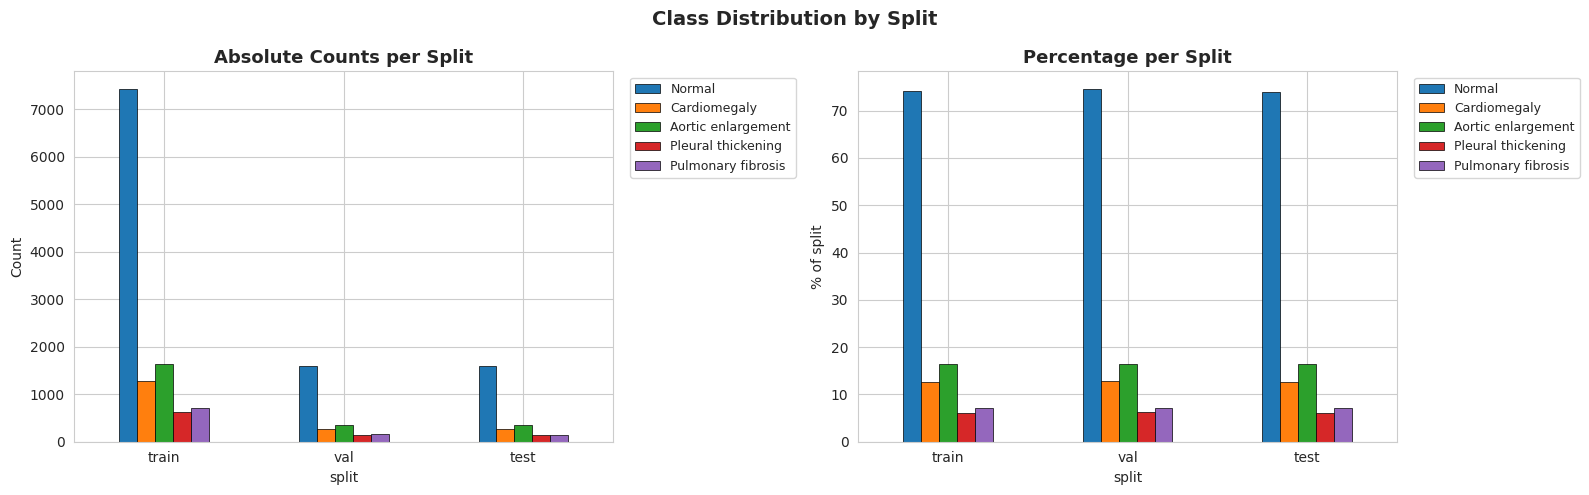

In [16]:
split_data = []
for split in ["train", "val", "test"]:
    sub = labels[labels["split"] == split]
    row = {"split": split, "Normal": int(sub["no finding"].sum())}
    for c in DISEASE_COLS:
        row[c] = int(sub[c].sum())
    row["total"] = len(sub)
    split_data.append(row)
split_df = pd.DataFrame(split_data).set_index("split")
display(split_df)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plot_cols = ["Normal"] + DISEASE_COLS

# Absolute counts
split_df[plot_cols].plot(kind="bar", ax=ax1, edgecolor="black", linewidth=0.5)
ax1.set_title("Absolute Counts per Split", fontsize=13, fontweight="bold")
ax1.set_ylabel("Count")
ax1.tick_params(axis="x", rotation=0)
ax1.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)

# Percentage
split_pct = split_df[plot_cols].div(split_df["total"], axis=0) * 100
split_pct.plot(kind="bar", ax=ax2, edgecolor="black", linewidth=0.5)
ax2.set_title("Percentage per Split", fontsize=13, fontweight="bold")
ax2.set_ylabel("% of split")
ax2.tick_params(axis="x", rotation=0)
ax2.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)

plt.suptitle("Class Distribution by Split", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "per_split_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Multi-Label Statistics

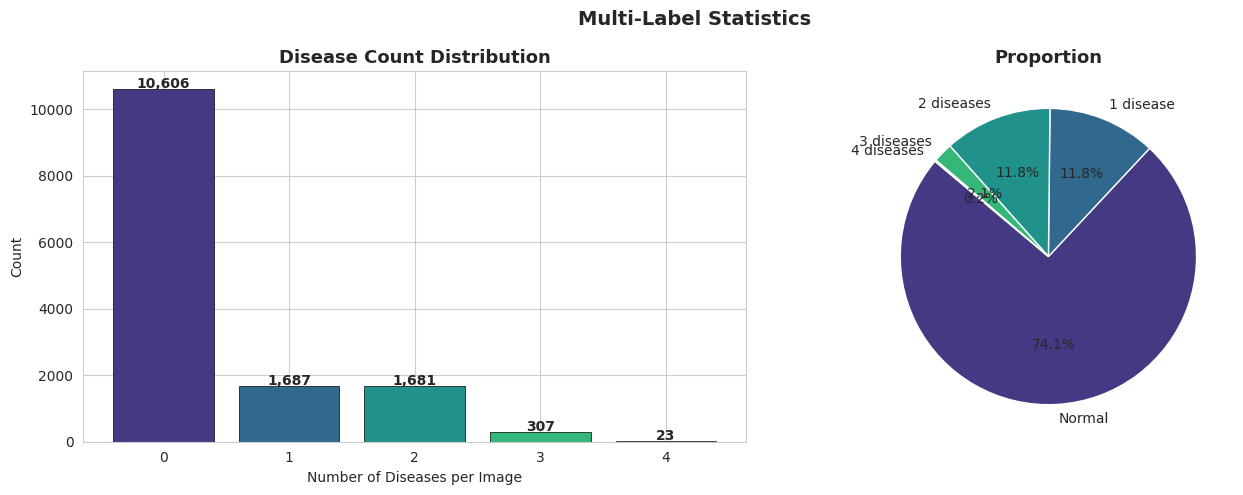


Images with multiple diseases: 2,011 (14.1%)


In [17]:
labels["n_diseases"] = labels[DISEASE_COLS].sum(axis=1).astype(int)
dist = labels["n_diseases"].value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette("viridis", len(dist))
bars = ax1.bar(dist.index, dist.values, color=colors, edgecolor="black", linewidth=0.5)
for b, v in zip(bars, dist.values):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 30, f"{v:,}",
             ha="center", fontsize=10, fontweight="bold")
ax1.set_xlabel("Number of Diseases per Image")
ax1.set_ylabel("Count")
ax1.set_title("Disease Count Distribution", fontsize=13, fontweight="bold")
ax1.set_xticks(dist.index)

# Pie
pie_labels = [f"{k} disease{'s' if k != 1 else ''}" if k > 0 else "Normal" for k in dist.index]
ax2.pie(dist.values, labels=pie_labels, autopct="%1.1f%%", colors=colors, startangle=140)
ax2.set_title("Proportion", fontsize=13, fontweight="bold")

plt.suptitle("Multi-Label Statistics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "multilabel_stats.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nImages with multiple diseases: {(labels['n_diseases'] > 1).sum():,} "
      f"({(labels['n_diseases'] > 1).mean()*100:.1f}%)")

## 7. Disease Co-occurrence

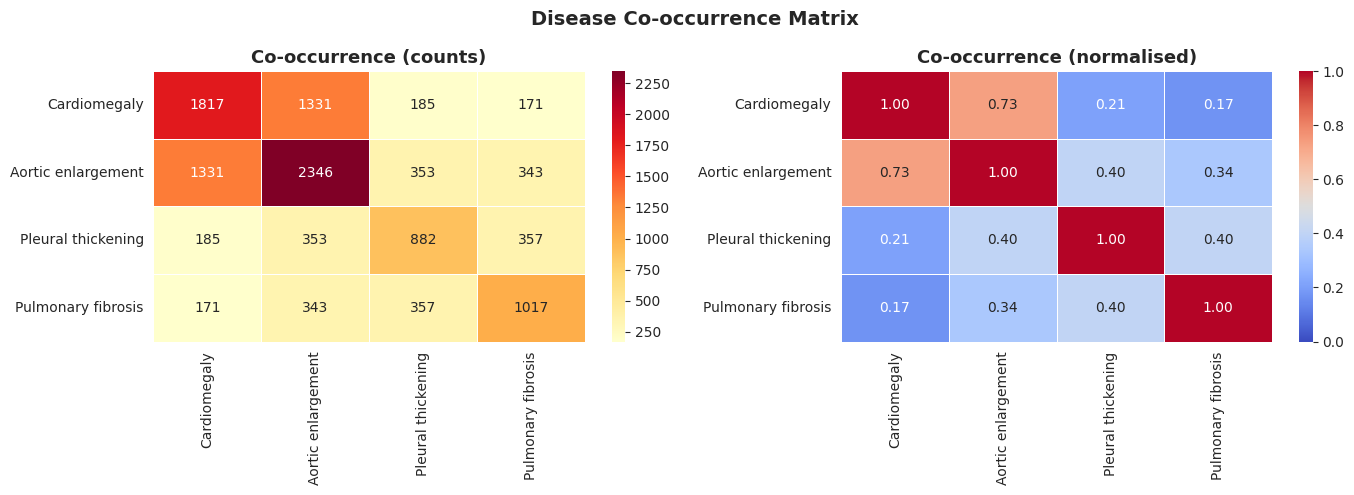

In [18]:
cooc = labels[DISEASE_COLS].T.dot(labels[DISEASE_COLS])
# Normalize for correlation
cooc_norm = cooc.copy().astype(float)
for i in range(len(DISEASE_COLS)):
    for j in range(len(DISEASE_COLS)):
        denom = min(cooc.iloc[i, i], cooc.iloc[j, j])
        cooc_norm.iloc[i, j] = cooc.iloc[i, j] / denom if denom > 0 else 0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cooc, annot=True, fmt="d", cmap="YlOrRd", ax=ax1, linewidths=0.5)
ax1.set_title("Co-occurrence (counts)", fontsize=13, fontweight="bold")

sns.heatmap(cooc_norm, annot=True, fmt=".2f", cmap="coolwarm", ax=ax2, linewidths=0.5,
            vmin=0, vmax=1)
ax2.set_title("Co-occurrence (normalised)", fontsize=13, fontweight="bold")

plt.suptitle("Disease Co-occurrence Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "cooccurrence_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Pixel Intensity Analysis

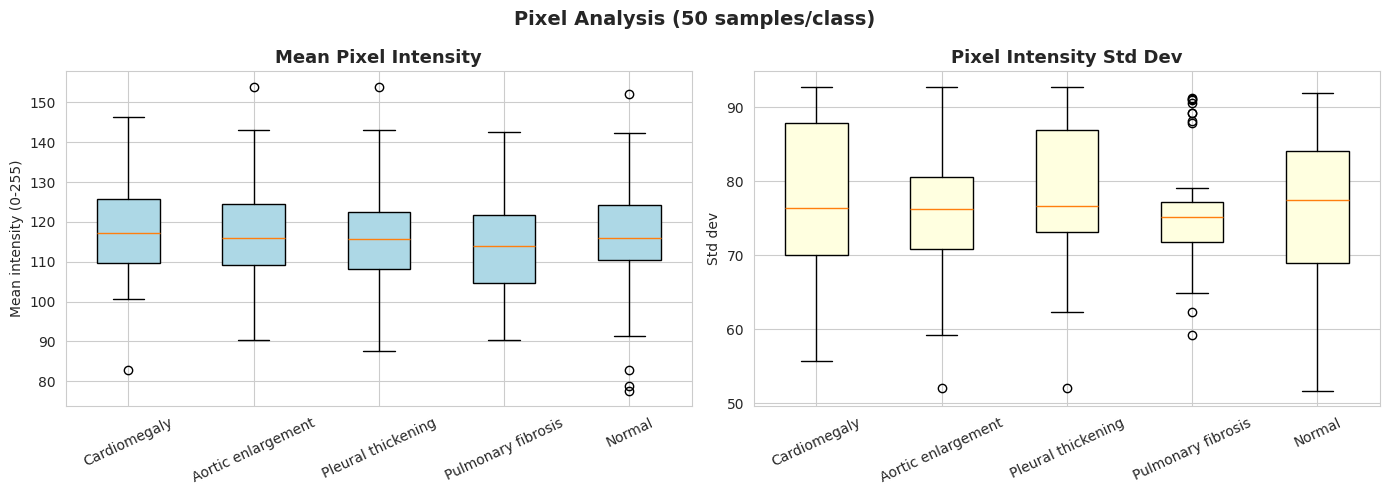

In [23]:
n_sample = 50
stats = {c: [] for c in DISEASE_COLS + ["Normal"]}
for c in DISEASE_COLS:
    fnames = labels[labels[c] == 1]["filename"].tolist()[:n_sample]
    for fn in fnames:
        p = resolve_image(fn, processed_dir)
        if p is not None and p.exists():
            img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
            stats[c].append({"mean": float(img.mean()), "std": float(img.std())})

normal_fnames = labels[labels["no finding"] == 1]["filename"].tolist()[:n_sample]
for fn in normal_fnames:
    p = resolve_image(fn, processed_dir)
    if p is not None and p.exists():
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        stats["Normal"].append({"mean": float(img.mean()), "std": float(img.std())})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
means = {c: [s["mean"] for s in v] for c, v in stats.items()}
stds  = {c: [s["std"]  for s in v] for c, v in stats.items()}

ax1.boxplot(means.values(), labels=means.keys(), patch_artist=True,
            boxprops=dict(facecolor="lightblue"))
ax1.set_title("Mean Pixel Intensity", fontsize=13, fontweight="bold")
ax1.tick_params(axis="x", rotation=25)
ax1.set_ylabel("Mean intensity (0-255)")

ax2.boxplot(stds.values(), labels=stds.keys(), patch_artist=True,
            boxprops=dict(facecolor="lightyellow"))
ax2.set_title("Pixel Intensity Std Dev", fontsize=13, fontweight="bold")
ax2.tick_params(axis="x", rotation=25)
ax2.set_ylabel("Std dev")

plt.suptitle(f"Pixel Analysis ({n_sample} samples/class)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "pixel_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Radiologist Agreement Analysis

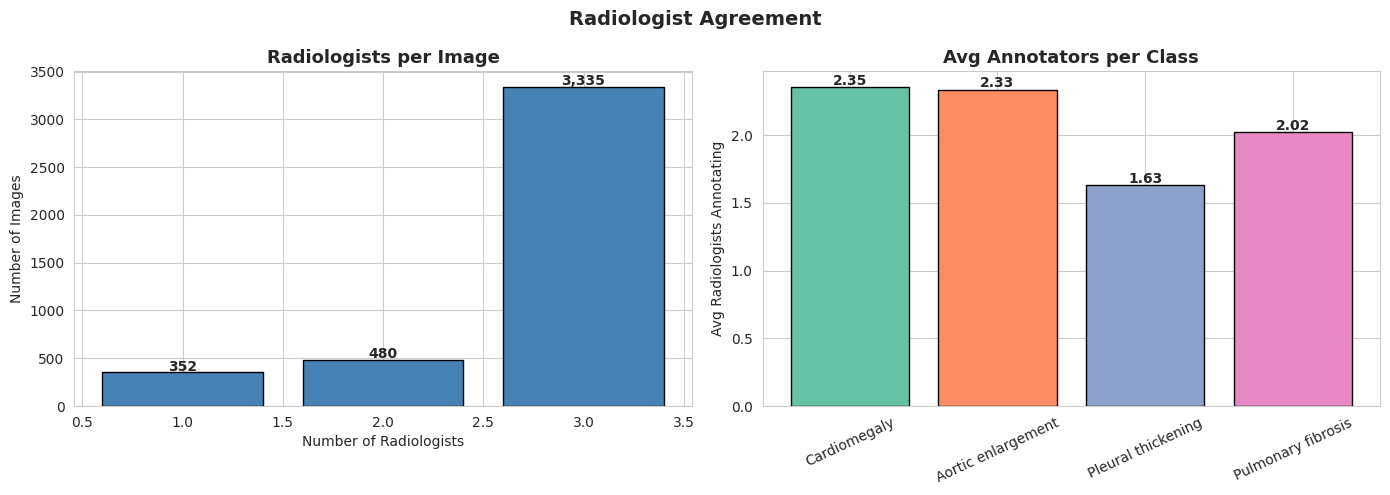

In [24]:
train_csv = pd.read_csv("data/vinbigdata-chest-xray-abnormalities-detection/train.csv")
target_classes = DISEASE_COLS + ["no finding"]

rad_data = train_csv[train_csv["class_name"].isin(target_classes)].copy()
rad_per_image = rad_data.groupby("image_id")["rad_id"].nunique()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Radiologists per image
rad_dist = rad_per_image.value_counts().sort_index()
ax1.bar(rad_dist.index, rad_dist.values, color="steelblue", edgecolor="black")
for x, y in zip(rad_dist.index, rad_dist.values):
    ax1.text(x, y + 20, f"{y:,}", ha="center", fontsize=10, fontweight="bold")
ax1.set_xlabel("Number of Radiologists")
ax1.set_ylabel("Number of Images")
ax1.set_title("Radiologists per Image", fontsize=13, fontweight="bold")

# Agreement per class
class_agreement = {}
for cls in target_classes:
    cls_data = rad_data[rad_data["class_name"] == cls]
    img_rads = cls_data.groupby("image_id")["rad_id"].nunique()
    class_agreement[cls] = img_rads.mean()

colors = sns.color_palette("Set2", len(class_agreement))
bars = ax2.bar(class_agreement.keys(), class_agreement.values(), color=colors, edgecolor="black")
for b, v in zip(bars, class_agreement.values()):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02, f"{v:.2f}",
             ha="center", fontsize=10, fontweight="bold")
ax2.set_ylabel("Avg Radiologists Annotating")
ax2.set_title("Avg Annotators per Class", fontsize=13, fontweight="bold")
ax2.tick_params(axis="x", rotation=25)

plt.suptitle("Radiologist Agreement", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "radiologist_agreement.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Image Metadata Analysis

In [26]:
import pydicom

dicom_dir = Path("data/vinbigdata-chest-xray-abnormalities-detection/train")
sample_fnames = labels["filename"].tolist()[:200]
meta_records = []

for fn in sample_fnames:
    p = resolve_image(fn, dicom_dir, prefer_ext=".dicom")
    if p is None or not p.exists():
        continue
    try:
        ds = pydicom.dcmread(str(p), stop_before_pixels=True)
        meta_records.append({
            "width": int(ds.Columns),
            "height": int(ds.Rows),
            "bits": int(ds.BitsStored),
            "photometric": str(getattr(ds, "PhotometricInterpretation", "N/A")),
        })
    except Exception:
        pass

if not meta_records:
    print("No DICOM metadata found — skipping plot.")
else:
    meta_df = pd.DataFrame(meta_records)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Dimensions scatter
    axes[0].scatter(meta_df["width"], meta_df["height"], alpha=0.4, s=20, c="steelblue")
    axes[0].set_xlabel("Width (px)")
    axes[0].set_ylabel("Height (px)")
    axes[0].set_title("Image Dimensions", fontsize=13, fontweight="bold")

    # Bits stored
    bits_dist = meta_df["bits"].value_counts().sort_index()
    axes[1].bar(bits_dist.index.astype(str), bits_dist.values, color="coral", edgecolor="black")
    for x, (idx, v) in enumerate(bits_dist.items()):
        axes[1].text(x, v + 1, f"{v}", ha="center", fontsize=10, fontweight="bold")
    axes[1].set_xlabel("Bits Stored")
    axes[1].set_title("Bits Stored Distribution", fontsize=13, fontweight="bold")

    # Photometric
    photo_dist = meta_df["photometric"].value_counts()
    axes[2].bar(photo_dist.index, photo_dist.values, color="mediumpurple", edgecolor="black")
    for x, (idx, v) in enumerate(photo_dist.items()):
        axes[2].text(x, v + 1, f"{v}", ha="center", fontsize=10, fontweight="bold")
    axes[2].set_xlabel("Photometric Interpretation")
    axes[2].set_title("Photometric Distribution", fontsize=13, fontweight="bold")

    plt.suptitle(f"DICOM Metadata ({len(meta_df)} samples)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(SAVE_DIR / "image_metadata.png", dpi=150, bbox_inches="tight")
    plt.show()

No DICOM metadata found — skipping plot.


## 11. Dataset Summary

In [28]:
total = len(labels)
n_normal = int(labels["no finding"].sum())
n_disease = total - n_normal
n_multi = int((labels["n_diseases"] > 1).sum())

summary = f"""
╔══════════════════════════════════════════════╗
║       XClinVision Dataset Summary            ║
╠══════════════════════════════════════════════╣
║  Total images       : {total:>6,}                ║
║  Normal images      : {n_normal:>6,} ({n_normal/total*100:5.1f}%)        ║
║  Disease images     : {n_disease:>6,} ({n_disease/total*100:5.1f}%)        ║
║  Multi-disease      : {n_multi:>6,} ({n_multi/total*100:5.1f}%)        ║
╠══════════════════════════════════════════════╣
║  Train / Val / Test : {len(splits['train']):,} / {len(splits['val']):,} / {len(splits['test']):,}     ║
╠══════════════════════════════════════════════╣"""

for c in DISEASE_COLS:
    cnt = int(labels[c].sum())
    summary += f"""
║  {c:<22}: {cnt:>5,} ({cnt/total*100:5.1f}%)        ║"""

summary += """
╚══════════════════════════════════════════════╝"""
print(summary)


╔══════════════════════════════════════════════╗
║       XClinVision Dataset Summary            ║
╠══════════════════════════════════════════════╣
║  Total images       : 14,304                ║
║  Normal images      : 10,606 ( 74.1%)        ║
║  Disease images     :  3,698 ( 25.9%)        ║
║  Multi-disease      :  2,011 ( 14.1%)        ║
╠══════════════════════════════════════════════╣
║  Train / Val / Test : 10,020 / 2,133 / 2,151     ║
╠══════════════════════════════════════════════╣
║  Cardiomegaly          : 1,817 ( 12.7%)        ║
║  Aortic enlargement    : 2,346 ( 16.4%)        ║
║  Pleural thickening    :   882 (  6.2%)        ║
║  Pulmonary fibrosis    : 1,017 (  7.1%)        ║
╚══════════════════════════════════════════════╝
